In [1]:
!pip install einops


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 1.3 MB/s eta 0:00:00


In [3]:
!ls -lh /kaggle/input/weightsuformer/Uformer_B.pth


-rw-r--r-- 1 nobody nogroup 585M Jan  4 13:05 /kaggle/input/weightsuformer/Uformer_B.pth


In [2]:
"""
generate_augmented_all.py

Run this script once on Kaggle (or locally) to physically create augmented images for 
all three datasets. Each dataset ends up with a /trainA_aug and /trainB_aug folder 
for the newly created augmented images.

You can then reference these newly created folders in your training script.
"""

import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from PIL import Image
import uuid

# Example offline augmentation pipeline
offline_augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    # Add more augmentations if desired
])

def generate_augmented_images(input_dir, target_dir, out_input_dir, out_target_dir):
    """
    Reads images from input_dir & target_dir, applies offline_augment,
    and saves new images to out_input_dir & out_target_dir.
    """
    if not os.path.exists(out_input_dir):
        os.makedirs(out_input_dir)
    if not os.path.exists(out_target_dir):
        os.makedirs(out_target_dir)

    filenames = os.listdir(input_dir)
    for fname in filenames:
        in_path = os.path.join(input_dir, fname)
        tar_path = os.path.join(target_dir, fname)
        if os.path.isfile(in_path) and os.path.isfile(tar_path):
            # Load images
            in_img = Image.open(in_path).convert('RGB')
            tar_img= Image.open(tar_path).convert('RGB')
            in_np  = np.array(in_img)
            tar_np = np.array(tar_img)

            # Apply offline augment
            augmented = offline_augment(image=in_np, mask=tar_np)
            aug_in  = augmented['image']
            aug_tar = augmented['mask']

            # Convert arrays back to PIL
            aug_in_pil = Image.fromarray(aug_in)
            aug_tar_pil= Image.fromarray(aug_tar)

            # Generate unique filenames to avoid collisions
            base, ext = os.path.splitext(fname)
            new_filename = f"{base}_aug_{uuid.uuid4().hex[:6]}{ext}"

            # Save augmented images
            aug_in_pil.save(os.path.join(out_input_dir, new_filename))
            aug_tar_pil.save(os.path.join(out_target_dir, new_filename))

if __name__ == "__main__":
    # Dataset 1 (example paths):
    d1_input_dir  = "/kaggle/input/datasetenhancementunderwater/underwater_dark/trainA"
    d1_target_dir = "/kaggle/input/datasetenhancementunderwater/underwater_dark/trainB"
    d1_aug_input  = "/kaggle/working/datasetenhancementunderwater/underwater_dark/trainA_aug_d1"
    d1_aug_target = "/kaggle/working/datasetenhancementunderwater/underwater_dark/trainB_aug_d1"

    print("Generating augmentations for Dataset 1...")
    generate_augmented_images(
        input_dir=d1_input_dir,
        target_dir=d1_target_dir,
        out_input_dir=d1_aug_input,
        out_target_dir=d1_aug_target
    )

    # Dataset 2
    d2_input_dir  = "/kaggle/input/underwaterimagenetdataset/underwater_imagenet/trainA"
    d2_target_dir = "/kaggle/input/underwaterimagenetdataset/underwater_imagenet/trainB"
    d2_aug_input  = "/kaggle/working/underwaterimagenetdataset/underwater_imagenet/trainA_aug_d2"
    d2_aug_target = "/kaggle/working/underwaterimagenetdataset/underwater_imagenet/trainB_aug_d2"

    print("Generating augmentations for Dataset 2...")
    generate_augmented_images(
        input_dir=d2_input_dir,
        target_dir=d2_target_dir,
        out_input_dir=d2_aug_input,
        out_target_dir=d2_aug_target
    )

    # Dataset 3
    d3_input_dir  = "/kaggle/input/underwaterscenesdataset/underwater_scenes/trainA"
    d3_target_dir = "/kaggle/input/underwaterscenesdataset/underwater_scenes/trainB"
    d3_aug_input  = "/kaggle/working/underwaterscenesdataset/underwater_scenes/trainA_aug_d3"
    d3_aug_target = "/kaggle/working/underwaterscenesdataset/underwater_scenes/trainB_aug_d3"

    print("Generating augmentations for Dataset 3...")
    generate_augmented_images(
        input_dir=d3_input_dir,
        target_dir=d3_target_dir,
        out_input_dir=d3_aug_input,
        out_target_dir=d3_aug_target
    )

    print("All augmentations complete!")


/opt/conda/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Generating augmentations for Dataset 1...
Generating augmentations for Dataset 2...
Generating augmentations for Dataset 3...
All augmentations complete!


/tmp/ipykernel_23/2252641238.py:221: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pretrained_weights, map_location=device)
/tmp/ipykernel_23/2252641

Pretrained loaded.


Epoch 1/20:   0%|          | 0/2573 [00:00<?, ?it/s]/tmp/ipykernel_23/2252641238.py:260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/20: 100%|██████████| 2573/2573 [17:18<00:00,  2.48it/s]
/tmp/ipykernel_23/2252641238.py:285: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/20] Train Loss:0.0013 | Val PSNR:21.75 | Val SSIM:0.8281
Best model saved with PSNR:21.75


Epoch 2/20: 100%|██████████| 2573/2573 [17:09<00:00,  2.50it/s]


...

Epoch [18/20] Train Loss:0.0009 | Val PSNR:22.59 | Val SSIM:0.8377


Epoch 19/20: 100%|██████████| 2573/2573 [17:15<00:00,  2.49it/s]


Epoch [19/20] Train Loss:0.0009 | Val PSNR:22.64 | Val SSIM:0.8403


Epoch 20/20: 100%|██████████| 2573/2573 [17:13<00:00,  2.49it/s]


Epoch [20/20] Train Loss:0.0009 | Val PSNR:22.76 | Val SSIM:0.8405
Best model saved with PSNR:22.76
Training Completed.
Printing one sample from the validation set with GT.


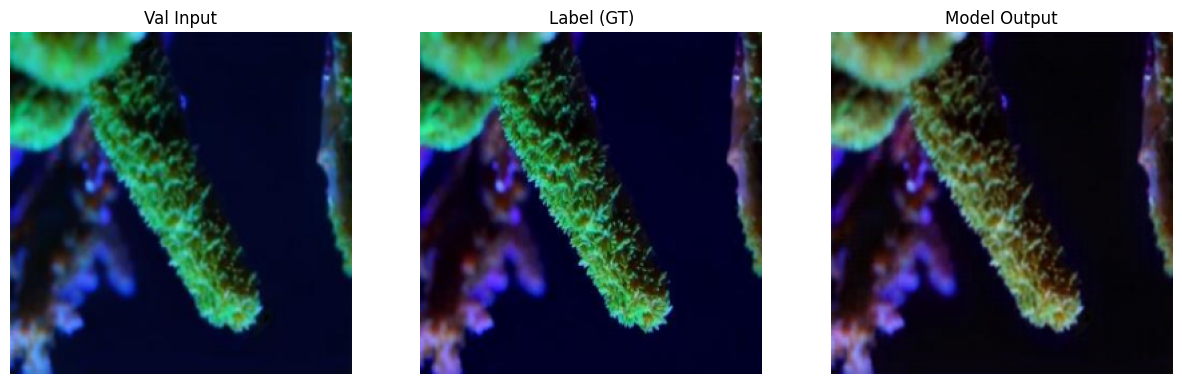

Now let's do final inference on the test set with no GT.


Final Inference:   0%|          | 0/570 [00:00<?, ?it/s]/tmp/ipykernel_23/2252641238.py:311: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Final Inference: 100%|██████████| 570/570 [00:42<00:00, 13.57it/s]

Done!


In [4]:
import os
import sys
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from PIL import Image
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt

# Install dependencies
!pip install torchmetrics albumentations==1.1.0 > /dev/null
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchmetrics

# Import Uformer
sys.path.append('/kaggle/input/modeluformer')
from model import Uformer

# -------------------
# Configuration
# -------------------
# Example directories for dataset1 original + augmented
d1_input_dir     = "/kaggle/input/datasetenhancementunderwater/underwater_dark/trainA"
d1_target_dir    = "/kaggle/input/datasetenhancementunderwater/underwater_dark/trainB"
# Changed paths to /kaggle/working for augmented
d1_aug_input_dir = "/kaggle/working/datasetenhancementunderwater/underwater_dark/trainA_aug_d1"
d1_aug_target_dir= "/kaggle/working/datasetenhancementunderwater/underwater_dark/trainB_aug_d1"

# Similarly for dataset2 (original + augmented)
d2_input_dir     = "/kaggle/input/underwaterimagenetdataset/underwater_imagenet/trainA"
d2_target_dir    = "/kaggle/input/underwaterimagenetdataset/underwater_imagenet/trainB"
d2_aug_input_dir = "/kaggle/working/underwaterimagenetdataset/underwater_imagenet/trainA_aug_d2"
d2_aug_target_dir= "/kaggle/working/underwaterimagenetdataset/underwater_imagenet/trainB_aug_d2"

# Similarly for dataset3 (original + augmented)
d3_input_dir     = "/kaggle/input/underwaterscenesdataset/underwater_scenes/trainA"
d3_target_dir    = "/kaggle/input/underwaterscenesdataset/underwater_scenes/trainB"
d3_aug_input_dir = "/kaggle/working/underwaterscenesdataset/underwater_scenes/trainA_aug_d3"
d3_aug_target_dir= "/kaggle/working/underwaterscenesdataset/underwater_scenes/trainB_aug_d3"

# The final test set with NO GT
final_test_dir = "/kaggle/input/datasetenhancementunderwater/underwater_dark/validation"  # user-specified no GT images

pretrained_weights = "/kaggle/input/weightsuformer/Uformer_B.pth"
img_size = (256,256)
batch_size = 8
accumulation_steps = 2
lr = 1e-4
num_epochs = 20
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Basic transform for physically saved images (both original + augmented)
basic_transform = A.Compose([
    A.Resize(height=img_size[0], width=img_size[1]),
    A.Normalize(mean=(0.0,0.0,0.0), std=(1.0,1.0,1.0)),
    ToTensorV2(),
], additional_targets={'target':'image'})

# -------------------
# PairedImageDiskDataset for loading from disk
# -------------------
class PairedImageDiskDataset(Dataset):
    def __init__(self, input_dir, target_dir, transform=None):
        self.input_dir = input_dir
        self.target_dir= target_dir
        self.filenames = os.listdir(self.input_dir)
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        in_path = os.path.join(self.input_dir, fname)
        tar_path= os.path.join(self.target_dir, fname)

        in_img = Image.open(in_path).convert('RGB')
        tar_img= Image.open(tar_path).convert('RGB')
        in_np  = np.array(in_img)
        tar_np = np.array(tar_img)

        if self.transform:
            augmented = self.transform(image=in_np, target=tar_np)
            in_tensor = augmented['image']
            tar_tensor= augmented['target']
        else:
            in_tensor= T.ToTensor()(in_img)
            tar_tensor= T.ToTensor()(tar_img)

        return in_tensor, tar_tensor

# Create dataset objects for original & augmented from each dataset
d1_orig = PairedImageDiskDataset(d1_input_dir, d1_target_dir, transform=basic_transform)
d1_aug  = PairedImageDiskDataset(d1_aug_input_dir, d1_aug_target_dir, transform=basic_transform)

d2_orig = PairedImageDiskDataset(d2_input_dir, d2_target_dir, transform=basic_transform)
d2_aug  = PairedImageDiskDataset(d2_aug_input_dir, d2_aug_target_dir, transform=basic_transform)

d3_orig = PairedImageDiskDataset(d3_input_dir, d3_target_dir, transform=basic_transform)
d3_aug  = PairedImageDiskDataset(d3_aug_input_dir, d3_aug_target_dir, transform=basic_transform)

# Combine them all
full_dataset = ConcatDataset([
    d1_orig, d1_aug,
    d2_orig, d2_aug,
    d3_orig, d3_aug
])

# 90% train, 10% val
train_size = int(0.9 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
val_loader_with_gt = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# The final test set with no GT
class NoGTDataset(Dataset):
    def __init__(self, input_dir, transform=None):
        self.input_dir = input_dir
        self.filenames = os.listdir(input_dir)
        self.transform = transform
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        fname = self.filenames[idx]
        path  = os.path.join(self.input_dir, fname)
        img   = Image.open(path).convert('RGB')
        img_np= np.array(img)

        no_gt_tf = A.Compose([
            A.Resize(height=img_size[0], width=img_size[1]),
            A.Normalize(mean=(0.0,0.0,0.0), std=(1.0,1.0,1.0)),
            ToTensorV2(),
        ])
        res = no_gt_tf(image=img_np)
        return res['image'], fname  # also return filename if you want to save results

final_test_dataset = NoGTDataset(final_test_dir)
final_test_loader  = DataLoader(
    final_test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

def psnr(pred, target, max_val=1.0):
    mse = torch.mean((pred - target)**2)
    if mse == 0:
        return 100.0
    return 20*math.log10(max_val / torch.sqrt(mse).item())

# For printing 1 random sample from the val_dataset with GT
def print_one_val_sample(model, val_dataset, device):
    """
    Print 1 image from the val_dataset (with GT).
    Show original input, label, and model result.
    """
    model.eval()
    if len(val_dataset)==0:
        print("Val dataset empty.")
        return
    # pick random or first
    i = random.randint(0, len(val_dataset)-1)
    input_tensor, label_tensor = val_dataset[i]
    input_tensor = input_tensor.unsqueeze(0).to(device)
    label_tensor = label_tensor.unsqueeze(0)

    with torch.no_grad():
        pred_tensor = model(input_tensor)

    # Convert to CPU + NumPy
    input_img = input_tensor.cpu().squeeze(0).permute(1,2,0).numpy()
    label_img = label_tensor.cpu().squeeze(0).permute(1,2,0).numpy()
    pred_img  = pred_tensor.cpu().squeeze(0).permute(1,2,0).numpy()
    input_img = np.clip(input_img, 0,1)
    label_img = np.clip(label_img, 0,1)
    pred_img  = np.clip(pred_img, 0,1)

    fig, axs = plt.subplots(1,3,figsize=(15,6))
    axs[0].imshow(input_img)
    axs[0].axis('off')
    axs[0].set_title("Val Input")

    axs[1].imshow(label_img)
    axs[1].axis('off')
    axs[1].set_title("Label (GT)")

    axs[2].imshow(pred_img)
    axs[2].axis('off')
    axs[2].set_title("Model Output")
    plt.show()

# Initialize Uformer
model = Uformer(img_size=256, embed_dim=32, win_size=8).to(device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

if os.path.exists(pretrained_weights):
    checkpoint = torch.load(pretrained_weights, map_location=device)
    try:
        model.load_state_dict(checkpoint, strict=False)
        print("Pretrained loaded.")
    except RuntimeError as e:
        print("Error:", e)
        model = torch.load(pretrained_weights, map_location=device)
        if torch.cuda.device_count() > 1:
            model = nn.DataParallel(model)
else:
    print("No pretrained, training from scratch.")

# Freeze 80% layers
params_list = list(model.named_parameters())
total_params= len(params_list)
freeze_count= int(0.8* total_params)
for i,(n,p) in enumerate(params_list):
    if i<freeze_count:
        p.requires_grad=False
    else:
        p.requires_grad=True

criterion = nn.MSELoss()
optimizer=optim.Adam(filter(lambda p:p.requires_grad, model.parameters()), lr=lr)

from torch.cuda.amp import autocast, GradScaler
scaler=GradScaler()
ssim_metric = torchmetrics.StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

best_psnr=-1
save_path='best_uformer_finetuned.pth'

for epoch in range(num_epochs):
    model.train()
    train_loss=0.0
    optimizer.zero_grad()

    for i,(inputs,targets) in enumerate(tqdm(train_loader,desc=f"Epoch {epoch+1}/{num_epochs}")):
        inputs,targets=inputs.to(device), targets.to(device)
        with autocast():
            outputs=model(inputs)
            loss=criterion(outputs, targets)
            loss=loss/accumulation_steps
        scaler.scale(loss).backward()
        if (i+1)%accumulation_steps==0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        train_loss+=loss.item()*accumulation_steps
    
    if (i+1)%accumulation_steps!=0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    train_loss/=len(train_loader.dataset)

    # Validation (with GT) for each epoch
    model.eval()
    val_psnr_values=[]
    val_ssim_values=[]
    with torch.no_grad():
        for inpt,tar in val_loader_with_gt:
            inpt,tar=inpt.to(device),tar.to(device)
            with autocast():
                out=model(inpt)
            val_psnr_values.append(psnr(out,tar))
            val_ssim_values.append(ssim_metric(out,tar).item())
    avg_val_psnr= sum(val_psnr_values)/len(val_psnr_values)
    avg_val_ssim= sum(val_ssim_values)/len(val_ssim_values)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss:{train_loss:.4f} | Val PSNR:{avg_val_psnr:.2f} | Val SSIM:{avg_val_ssim:.4f}")

    if avg_val_psnr>best_psnr:
        best_psnr=avg_val_psnr
        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), save_path)
        else:
            torch.save(model.state_dict(), save_path)
        print(f"Best model saved with PSNR:{best_psnr:.2f}")

print("Training Completed.")
print("Printing one sample from the validation set with GT.")
print_one_val_sample(model, val_dataset, device)

print("Now let's do final inference on the test set with no GT.")
model.eval()
with torch.no_grad():
    for inputs, fname in tqdm(final_test_loader, desc="Final Inference"):
        inputs=inputs.to(device)
        with autocast():
            preds=model(inputs)
        # You can save or process preds here
print("Done!")


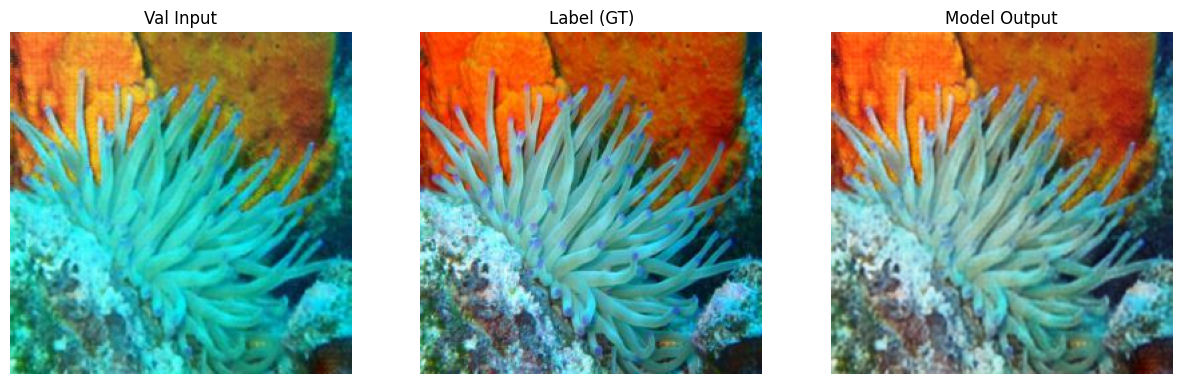

In [13]:
print_one_val_sample(model, val_dataset, device)


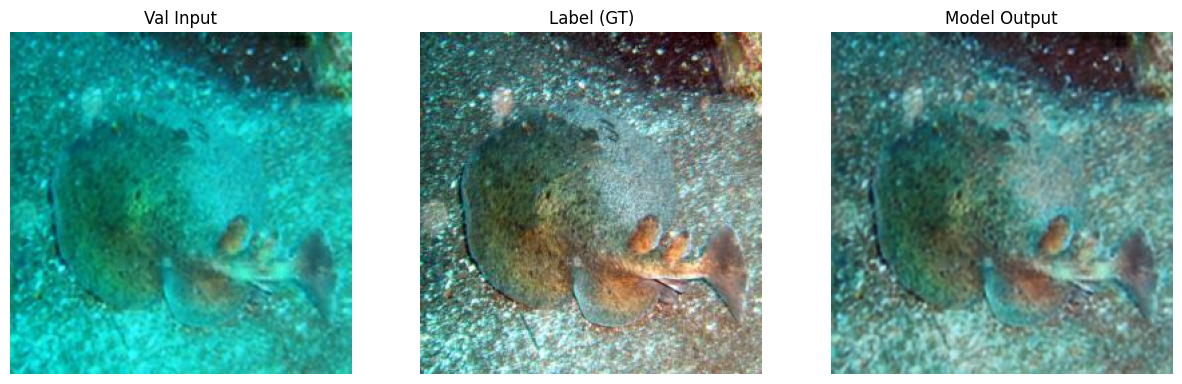

In [14]:
print_one_val_sample(model, val_dataset, device)


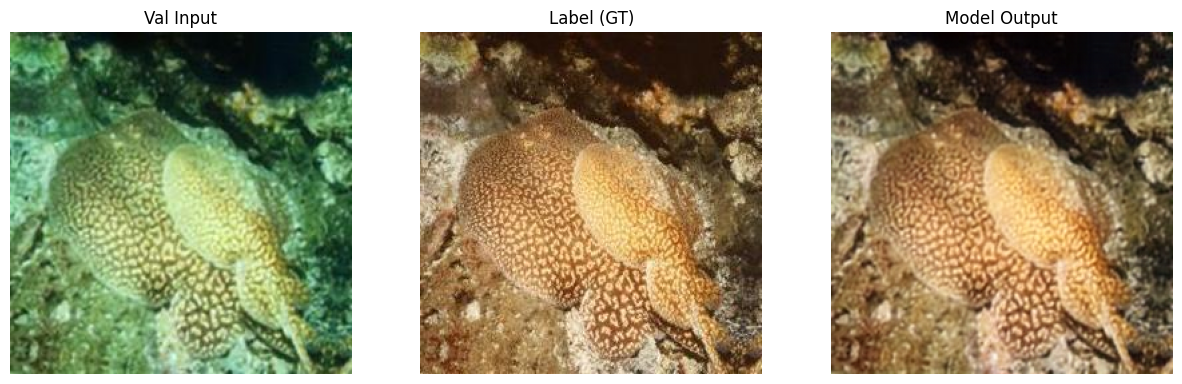

In [15]:
print_one_val_sample(model, val_dataset, device)


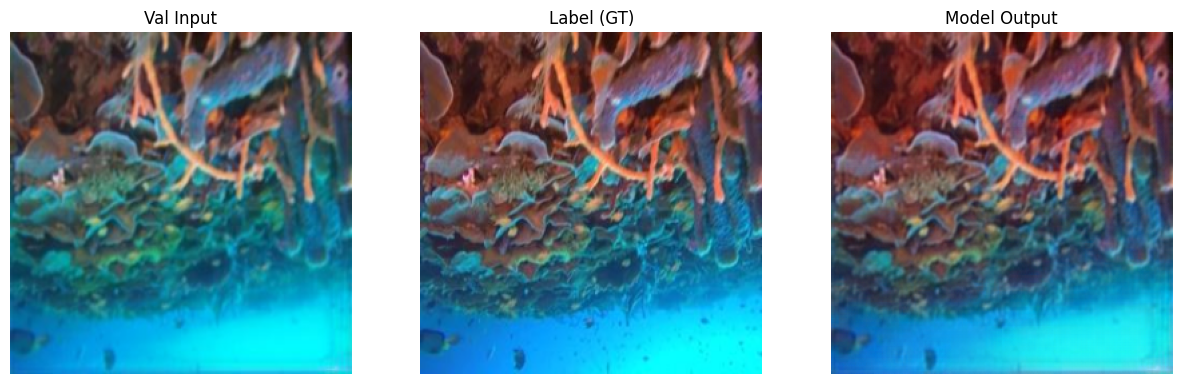

In [16]:
print_one_val_sample(model, val_dataset, device)


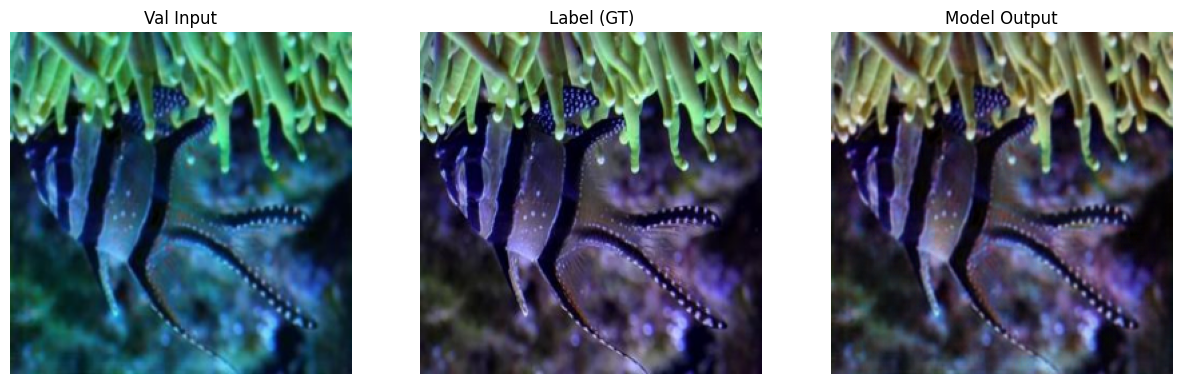

In [17]:
print_one_val_sample(model, val_dataset, device)


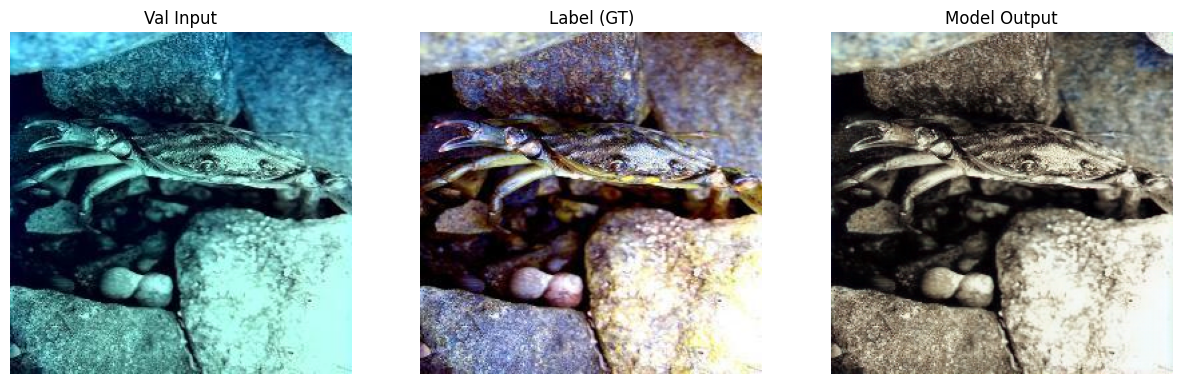

In [18]:
print_one_val_sample(model, val_dataset, device)


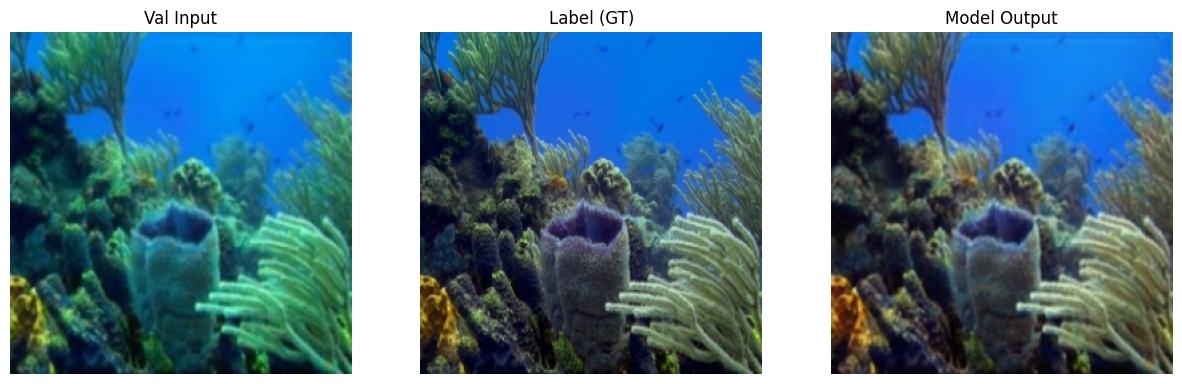

In [19]:
print_one_val_sample(model, val_dataset, device)


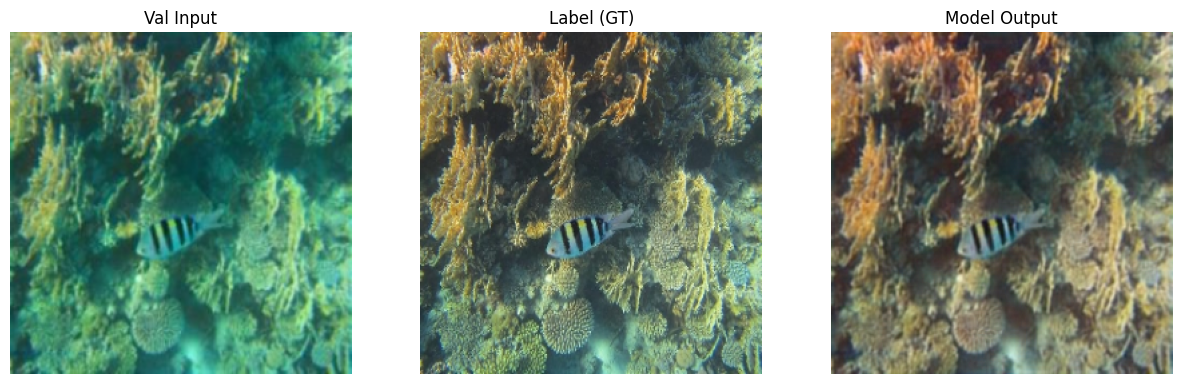

In [20]:
print_one_val_sample(model, val_dataset, device)
